### Normalize and correct sgRNA Log Fold Change data
#### adapted from Fortin et al, 2019
#### by Stefanus Bernard

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from _03_01_function_to_normalize_sgrna_lfc import *

In [3]:
read_count = pd.read_csv("../data/sgrna_lfc_data/tkov3_data/matrix-reads-by-gRNA-RPE1-drugZ.txt", sep ='\t')
read_count[['gene', 'sgRNA']] = read_count['sgRNA'].str.split('_', n = 1, expand=True)

# drop control genes (luciferase, LacZ, and EGPF)
read_count = read_count[~read_count['gene'].str.contains('LacZ|luciferase|EGPF', case=False)]
read_count = read_count.drop(columns=['GENE', 'gene'])
read_count = read_count.rename(columns={'sgRNA':'spacer'})

# filtered out sgRNA with less than 30 reads in T0
read_count = read_count[read_count['RPE1_T0'] > 30]

# drop LOPRIMER data
read_count = read_count[['spacer', 'RPE1_T0', 'RPE1_T3A_CTRL', 'RPE1_T3B_CTRL']]
display(read_count)

,spacer,RPE1_T0,RPE1_T3A_CTRL,RPE1_T3B_CTRL
0,ACTGGCGCCATCGAGAGCCA,164,93,44
1,CAAGAGAAAGACCACGAGCA,492,288,222
2,GCTCAGCTGGGTCCATCCTG,258,49,5
3,GTCGAGCTGATTCTGAGCGA,487,360,290
4,AGTTATGTTAGGTATACCCG,149,133,140
...,...,...,...,...
71061,GAGTGACAGACTCTTCGCCG,476,261,108
71062,AAGAAGTAGAATCTCGACGC,78,20,12
71063,AAGACCTTGAAAGTTTAGGC,48,0,10
71064,AGATGGTTCAGGTTCTCCGG,261,76,66


In [4]:
# import library data
library_data = pd.read_csv("../data/library_data/tkov3_guide_sequence.tsv", sep ="\t", header = None)
library_data.columns = ['sgRNA', 'spacer', 'gene']
display(library_data.shape)

# import common essential genes
list_common_essential = import_common_essential()

(71090, 3)

In [5]:
read_count = pd.merge(read_count, library_data, how="left", on="spacer").set_index(['sgRNA', 'spacer', 'gene']).sort_values(by="sgRNA")
read_count

,,,RPE1_T0,RPE1_T3A_CTRL,RPE1_T3B_CTRL
sgRNA,spacer,gene,,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,492,288,222
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,258,49,5
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,164,93,44
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,487,360,290
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,190,96,53
...,...,...,...,...,...
sgZZEF1_4,ATGGCAGTGCCTGTTCACAC,ZZEF1,991,665,478
sgZZZ3_1,AGATGGTTCAGGTTCTCCGG,ZZZ3,261,76,66
sgZZZ3_2,AAGACCTTGAAAGTTTAGGC,ZZZ3,48,0,10


In [6]:
# we log transformed the raw read counts (log2(counts + 1))

# separate plasmid count into a new column
# plasmid_count = read_count['RPE1_T0']
# plasmid_count

# main log transformed read count
# log_transformed_read_count = read_count.drop(columns=['RPE1_T0'])
log_transformed_read_count = np.log2(read_count + 1)
log_transformed_read_count

,,,RPE1_T0,RPE1_T3A_CTRL,RPE1_T3B_CTRL
sgRNA,spacer,gene,,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,8.945444,8.174926,7.800900
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,8.016808,5.643856,2.584963
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,7.366322,6.554589,5.491853
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,8.930737,8.495855,8.184875
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,7.577429,6.599913,5.754888
...,...,...,...,...,...
sgZZEF1_4,ATGGCAGTGCCTGTTCACAC,ZZEF1,9.954196,9.379378,8.903882
sgZZZ3_1,AGATGGTTCAGGTTCTCCGG,ZZZ3,8.033423,6.266787,6.066089
sgZZZ3_2,AAGACCTTGAAAGTTTAGGC,ZZZ3,5.614710,0.000000,3.459432


In [7]:
RPE1_T0 = log_transformed_read_count[['RPE1_T0']]

# Compute log-fold change relative to T0
sgrna_lfc = log_transformed_read_count.drop(columns=['RPE1_T0']).subtract(RPE1_T0.values, axis = 0)
sgrna_lfc

,,,RPE1_T3A_CTRL,RPE1_T3B_CTRL
sgRNA,spacer,gene,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,-0.770518,-1.144544
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,-2.372952,-5.431846
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,-0.811733,-1.874469
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,-0.434882,-0.745862
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,-0.977516,-1.822541
...,...,...,...,...
sgZZEF1_4,ATGGCAGTGCCTGTTCACAC,ZZEF1,-0.574818,-1.050314
sgZZZ3_1,AGATGGTTCAGGTTCTCCGG,ZZZ3,-1.766636,-1.967334
sgZZZ3_2,AAGACCTTGAAAGTTTAGGC,ZZZ3,-5.614710,-2.155278


In [8]:
# Center LFCs using non-essential guides
non_essential_mask = ~log_transformed_read_count.index.get_level_values(2).isin(list_common_essential)
median_non_essential = sgrna_lfc[non_essential_mask].median(axis=0)

median_non_essential

RPE1_T3A_CTRL   -0.944858
RPE1_T3B_CTRL   -1.359081
dtype: float64

In [9]:
# Subtract median of non-essential guides for each sample (normalized sgrna LFC)
sgrna_lfc_normalized = sgrna_lfc - median_non_essential
sgrna_lfc_normalized

,,,RPE1_T3A_CTRL,RPE1_T3B_CTRL
sgRNA,spacer,gene,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,0.174340,0.214537
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,-1.428094,-4.072765
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,0.133125,-0.515388
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,0.509976,0.613219
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,-0.032658,-0.463460
...,...,...,...,...
sgZZEF1_4,ATGGCAGTGCCTGTTCACAC,ZZEF1,0.370041,0.308767
sgZZZ3_1,AGATGGTTCAGGTTCTCCGG,ZZZ3,-0.821778,-0.608253
sgZZZ3_2,AAGACCTTGAAAGTTTAGGC,ZZZ3,-4.669851,-0.796197


In [10]:
# scaled sgRNA log fold change by centering around the median LFC of guides targeting essential genes
norm_sgrna_lfc_scaled, list_common_essential = scale_essential(sgrna_lfc_normalized)
norm_sgrna_lfc_scaled

Scale factor:  1.8928738417916966


,,,RPE1_T3A_CTRL,RPE1_T3B_CTRL
sgRNA,spacer,gene,,
sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,0.092103,0.113339
sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,-0.754458,-2.151630
sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,0.070330,-0.272278
sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,0.269419,0.323962
sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,-0.017253,-0.244845
...,...,...,...,...
sgZZEF1_4,ATGGCAGTGCCTGTTCACAC,ZZEF1,0.195491,0.163121
sgZZZ3_1,AGATGGTTCAGGTTCTCCGG,ZZZ3,-0.434143,-0.321338
sgZZZ3_2,AAGACCTTGAAAGTTTAGGC,ZZZ3,-2.467070,-0.420629


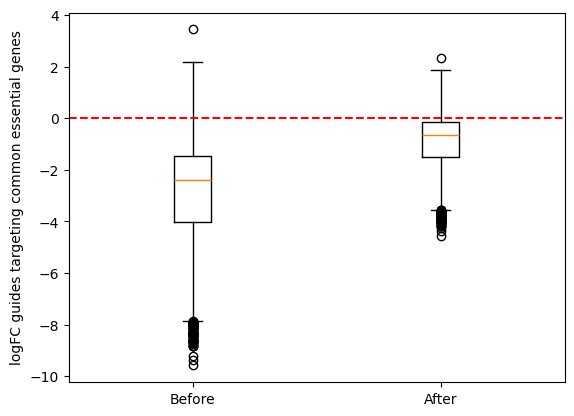

In [11]:
# check whether the normalization works (the median of lfc data should be around 0)
sanity_check_scale_essential(sgrna_lfc, norm_sgrna_lfc_scaled, list_common_essential)

In [12]:
# averaged sgRNA LFC across replicates
lfc_norm_scaled_avg = mean_row(norm_sgrna_lfc_scaled)
lfc_norm_scaled_avg = lfc_norm_scaled_avg.reset_index()
lfc_norm_scaled_avg

,sgRNA,spacer,gene,mean
0,sgA1BG_1,CAAGAGAAAGACCACGAGCA,A1BG,0.102721
1,sgA1BG_2,GCTCAGCTGGGTCCATCCTG,A1BG,-1.453044
2,sgA1BG_3,ACTGGCGCCATCGAGAGCCA,A1BG,-0.100974
3,sgA1BG_4,GTCGAGCTGATTCTGAGCGA,A1BG,0.296690
4,sgA1CF_1,TGCGCTGGACCAGTGCGCGG,A1CF,-0.131049
...,...,...,...,...
69951,sgZZEF1_4,ATGGCAGTGCCTGTTCACAC,ZZEF1,0.179306
69952,sgZZZ3_1,AGATGGTTCAGGTTCTCCGG,ZZZ3,-0.377741
69953,sgZZZ3_2,AAGACCTTGAAAGTTTAGGC,ZZZ3,-1.443849
69954,sgZZZ3_3,GACCAATATACCCATAGCCT,ZZZ3,0.959227


In [13]:
lfc_norm_scaled_avg.to_csv("../data/sgrna_lfc_data/output_normalized/tkov3_rpe1_normalized_lfc.csv", index=False)